<a href="https://colab.research.google.com/github/pushpalathanagarjun/AL_ML/blob/main/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('natural_disasters_2024.xlsx')

In [3]:
df.head()

,Disaster_ID,Disaster_Type,Location,Magnitude,Month,Fatalities,Economic_Loss($)
0,1,Wildfire,Brazil,6.267393,January,9706,6.509790e+08
1,2,Hurricane,Indonesia,6.649358,January,2233,5.538357e+08
2,3,Tornado,China,9.724366,January,478,6.910998e+07
3,4,Flood,India,1.702505,January,2867,8.474880e+08
4,5,Flood,Brazil,7.917748,January,776,6.449297e+08


In [5]:
df.groupby('Disaster_Type')['Economic_Loss($)'].mean()

,Economic_Loss($)
Disaster_Type,
Earthquake,4.972542e+08
Flood,5.065814e+08
Hurricane,5.100738e+08
Tornado,5.071573e+08
Wildfire,5.040347e+08


In [7]:
df.groupby('Disaster_Type')['Economic_Loss($)'].mean().sort_values(ascending=False)

,Economic_Loss($)
Disaster_Type,
Hurricane,5.100738e+08
Tornado,5.071573e+08
Flood,5.065814e+08
Wildfire,5.040347e+08
Earthquake,4.972542e+08


In [8]:
df.groupby('Disaster_Type')['Fatalities'].median()

,Fatalities
Disaster_Type,
Earthquake,4900.5
Flood,5029.5
Hurricane,5028.0
Tornado,4938.5
Wildfire,4828.0


In [9]:
df.groupby('Disaster_Type').count()

,Disaster_ID,Location,Magnitude,Month,Fatalities,Economic_Loss($)
Disaster_Type,,,,,,
Earthquake,2036,2036,2036,2036,2036,2036
Flood,2018,2018,2018,2018,2018,2018
Hurricane,1952,1952,1952,1952,1952,1952
Tornado,2012,2012,2012,2012,2012,2012
Wildfire,1982,1982,1982,1982,1982,1982


In [13]:
df['Magnitude'].max()
df['Magnitude'].min()

1.00065552866037

In [14]:
# finding MAD
from scipy import stats
import numpy as np

# Mean Absolute Deviation using SciPy
mad_scipy = stats.median_abs_deviation(df.groupby('Disaster_Type')['Fatalities'], center=np.mean)
print(mad_scipy)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (5, 2) + inhomogeneous part.

In [15]:
# Variance within each Disaster type
df.groupby('Disaster_Type')['Economic_Loss($)'].var()

,Economic_Loss($)
Disaster_Type,
Earthquake,8.168568e+16
Flood,8.376813e+16
Hurricane,8.209303e+16
Tornado,8.303293e+16
Wildfire,7.880561e+16


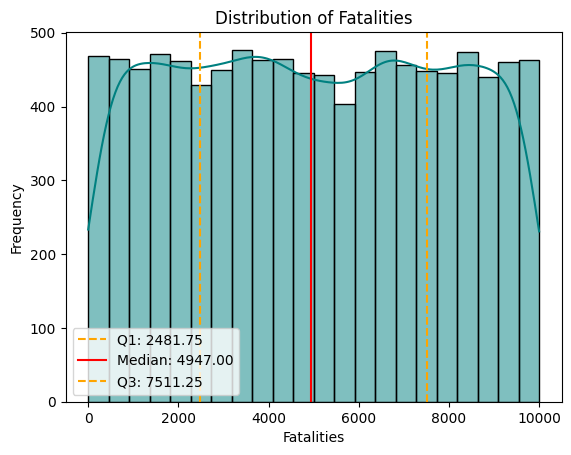

In [23]:
# Histogram of Fatalities with Quartiles
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = df['Fatalities']
q1, median, q3 = np.percentile(data, [25, 50, 75])

# Plot using Seaborn
sns.histplot(data,  kde = True, color="teal") #kde draws the curved line
plt.title("Distribution of Fatalities")
plt.xlabel("Fatalities")
plt.ylabel("Frequency")

# Add quartile lines
plt.axvline(q1, color='orange', linestyle='--', label=f'Q1: {q1:.2f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(q3, color='orange', linestyle='--', label=f'Q3: {q3:.2f}')

plt.legend()#displays the legend (key) on your plot, identifying what the different colors, markers, or lines represent.
plt.show()

In [24]:
# Finding the correlation between Fatalities and Economic loss
df.groupby('Disaster_Type')['Fatalities'].corr(df['Economic_Loss($)'])

,Fatalities
Disaster_Type,
Earthquake,0.027037
Flood,0.010188
Hurricane,0.001211
Tornado,-0.013404
Wildfire,0.017289


np.float64(0.008628181814866331)